# Experiment 1

Idea: With a given probability randomly allocate price within the range otherwise give
best action as suggested by policy

In [1]:
import copy

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from stable_baselines3.ppo import PPO

from fair_dynamic_pricing_with_rl.utils.demand_model import DemandModelEstimator
from fair_dynamic_pricing_with_rl.utils.env import FMCGEnv
from fair_dynamic_pricing_with_rl.utils.fairness_utils import compute_jains_index


In [2]:
unit_sales = pd.read_csv("../data/sales_train_evaluation.csv")
prices = pd.read_csv("../data/sell_prices.csv")
calendar = pd.read_csv("../data/calendar.csv")

In [3]:
demand_model_estimator = DemandModelEstimator(
    unit_sales_df = unit_sales,
    prices_df = prices,
    calendar_df = calendar,
    price_granularity = 0.001,
    verbose = True
)

demand_model_parameters = demand_model_estimator.run_pipeline()

--- Fitting demand model for FOODS_1_096 ---
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.638
Model:                            OLS   Adj. R-squared:                  0.636
Method:                 Least Squares   F-statistic:                     325.1
Date:                Tue, 28 Jul 2026   Prob (F-statistic):          1.13e-279
Time:                        18:02:40   Log-Likelihood:                -3366.3
No. Observations:                1300   AIC:                             6749.
Df Residuals:                    1292   BIC:                             6790.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------

In [4]:
# Register the environment so we can create it with gym.make()
gym.register(
    id="gymnasium_env/FMCGEnv",
    entry_point=FMCGEnv,
    max_episode_steps=500,  # Prevent infinite episodes
)

In [5]:
env = gym.make("gymnasium_env/FMCGEnv",
               p_min=np.array([5.0,5.0]),
               p_max=np.array([9.0,9.0]),
               p_diff=np.array([0.01,0.01]),
               betas=[params.to_numpy() for params in demand_model_parameters[3]],
               max_demand=demand_model_parameters[4],
               n_snap_days=10,
               calendar_seed=42,
               noise_range=1
               )

In [6]:
# PPO hyperparameters from Liu et al. (2024)
model = PPO(policy="MultiInputPolicy",
            env=env,
            learning_rate=0.0001,
            batch_size=64, # default
            clip_range=0.2, # default
            seed=42)

# no warm-up following Liu et al. (2024)
model.learn(total_timesteps=6000,
             progress_bar=True)

c:\Users\Kim Levente\AppData\Local\Programs\Python\Python313\Lib\site-packages\rich\live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

In [7]:
def running_model(env1,
                  alg,
                  T,
                  K,
                  num_products,
                  random_action_prob=0.5,
                  seed=None
                  ):
    """ PPO algorithm with some probability of choosing an action randomly.

    Args:
        env1 (FMCGEnv): the defined gym environment
        alg (stable_baselines3.PPO): PPO policy
        T (int): number of timesteps per episode
        K (int): number of episodes
        num_products (int): number of products
        random_action_prob (float): probability of choosing random action (in [0.0-1.0])
        seed (int): seed for reproducibility

    Returns:
        rew (np.ndarray): rewards (T,K)
        action_hist (np.ndarray): action history (T,K,L)
        groups (np.ndarray): groups according to binary sensitive attribute (T,K)
    """

    env = copy.deepcopy(env1)

    # dedicated RNG for random action override plus seeding action sampler
    rng = np.random.default_rng(seed)
    env.action_space.seed(seed)

    rew = np.zeros((T,K))
    action_hist = np.zeros((T,K,num_products))
    groups = np.zeros((T,K))

    for k in range(K):
        # sample initial state
        # seed each reset deterministically but distinctly per episode
        observation, info = env.reset(seed=None if seed is None else seed + k)

        for t in range(T):
            # save the group wrt. sensitive attribute
            groups[t,k] = observation['sensitive_attr']
            
            # take action using trained model
            action, _states = alg.predict(observation, deterministic=True)
            a = np.asarray(action)
            
            # with random_action_prob override with a random action
            if rng.random() < random_action_prob:
                a = env.action_space.sample()
                a = np.asarray(a)
            
            action_hist[t,k] = a

            # record new state/reward from action played
            observation, reward, terminated, truncated, info = env.step(a)

            rew[t,k] = reward
        
    return rew, action_hist, groups

In [8]:
# experiment 1 parameters
random_probs_list = [0.0,0.5,0.7,1.0]
K = 1000
P_MIN = np.array([5.0,5.0])
P_DIFF = np.array([0.01,0.01])

In [9]:
# storing expected mean episode rewards
episode_rewards_comparison = np.zeros((K*len(random_probs_list),3))
# storing Jain's indexes and mean episode revenues
results = pd.DataFrame(np.zeros((len(random_probs_list),5)),columns=["mean_episode_revenue","jains_index","random_action_prob", "nonsnap_price", "snap_price"])

action_histories = {}
all_rewards = {}

for idx in range(len(random_probs_list)):

    rewards, action_hist, groups = running_model(env1=env,
                                             alg=model,
                                             T=60,
                                             K=K,
                                             num_products=2,
                                             random_action_prob=random_probs_list[idx],
                                             seed=42)

    # save action histories & rewards for further analysis
    action_histories[random_probs_list[idx]] = action_hist
    all_rewards[random_probs_list[idx]] = rewards
 
    episode_rewards = rewards.sum(axis=0)
    e_mean_episode_reward = episode_rewards.cumsum() / (np.arange(K) + 1)

    # expected mean episode rewards
    episode_rewards_comparison[(idx*K):((idx+1)*K),0] = np.arange(K)
    episode_rewards_comparison[(idx*K):((idx+1)*K),1] = e_mean_episode_reward

    # random action probability
    episode_rewards_comparison[(idx*K):((idx+1)*K),2] = random_probs_list[idx]

    # save main performance metrics
    results.loc[idx,"random_action_prob"] = random_probs_list[idx]
    results.loc[idx,"mean_episode_revenue"] = episode_rewards.mean()
    results.loc[idx, "jains_index"], group_values = compute_jains_index(action_hist, groups, p_min=P_MIN, p_diff=P_DIFF)
    results.loc[idx, "nonsnap_price"] = group_values[False]
    results.loc[idx, "snap_price"] = group_values[True]


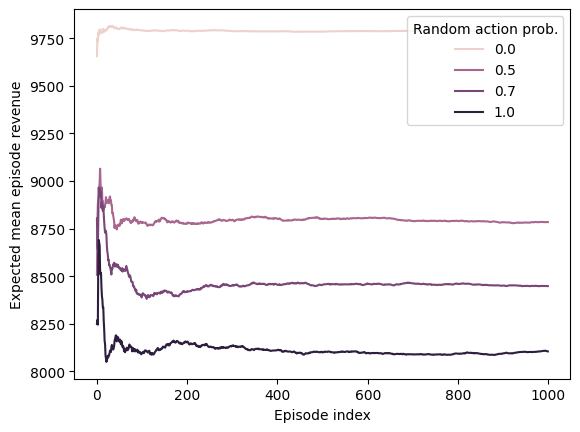

In [10]:
episode_rewards_comparison_df = pd.DataFrame(episode_rewards_comparison,
                                             columns=["episode_idx", "mean_episode_revenue", "random_action_prob"])

# for plotting every episode ex. first x: data = episode_rewards_comparison_df.loc[episode_rewards_comparison_df.episode_idx > 50.0],
sns.lineplot(data = episode_rewards_comparison_df,
             x="episode_idx",
             y="mean_episode_revenue",
             hue="random_action_prob")
plt.xlabel("Episode index")
plt.ylabel("Expected mean episode revenue")
plt.legend(title="Random action prob.")
plt.show()

In [11]:
# edge of pure PPO over baseline completely random algorithm wrt mean episode revenue over all episodes
mean_episode_revenues = episode_rewards_comparison_df.loc[episode_rewards_comparison_df.episode_idx==999,:]
mean_episode_revenue_ppo = mean_episode_revenues.loc[mean_episode_revenues.random_action_prob==0.0, "mean_episode_revenue"].to_numpy()[0]
mean_episode_revenue_random = mean_episode_revenues.loc[mean_episode_revenues.random_action_prob==1.0, "mean_episode_revenue"].to_numpy()[0]

print(f"Pure PPO achieved a mean per-episode reward of {mean_episode_revenue_ppo:.4f}, while the truly random policy: {mean_episode_revenue_random:.4f}.")
print(f"This represents an {(mean_episode_revenue_ppo/mean_episode_revenue_random-1)*100:.2f}% edge for the pure PPO policy over truly random.")

Pure PPO achieved a mean per-episode reward of 9787.6782, while the truly random policy: 8104.9929.
This represents an 20.76% edge for the pure PPO policy over truly random.


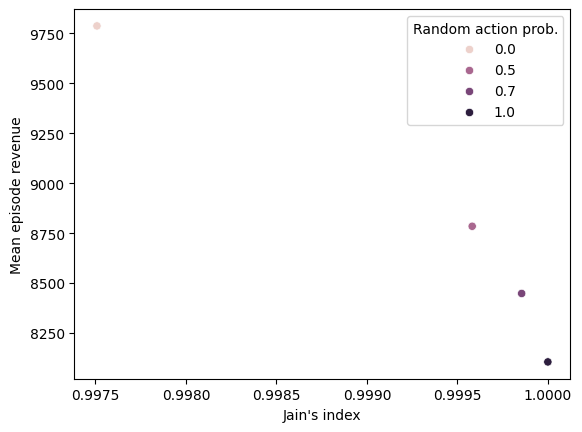

In [12]:
sns.scatterplot(data=results, x="jains_index", y="mean_episode_revenue",
                hue="random_action_prob")
plt.xlabel("Jain's index")
plt.ylabel("Mean episode revenue")
plt.legend(title="Random action prob.")
plt.show()

In [13]:
print(results)

   mean_episode_revenue  jains_index  random_action_prob  nonsnap_price  \
0           9787.678235     0.997508                 0.0      11.630213   
1           8784.326187     0.999581                 0.5      12.860445   
2           8447.823354     0.999855                 0.7      13.323764   
3           8104.992852     0.999999                 1.0      14.013750   

   snap_price  
0   12.853866  
1   13.397865  
2   13.649092  
3   13.989614  


In [100]:
prob = 0.0

actions = action_histories[prob]
rewards = all_rewards[prob]

T, K, L = actions.shape
prices = np.zeros((T, K, L))
for product_idx in range(L):
    prices[:,:,product_idx] = np.round(P_MIN[product_idx] + action_hist[:,:,product_idx] * P_DIFF[product_idx], 10)

# actions: (T, K, 2)   rewards: (T, K)
df = pd.DataFrame({
    "p0": prices[..., 0].ravel(),   # C-order: (t,k) pairs align across all three
    "p1": prices[..., 1].ravel(),
    "reward": rewards.ravel(),
})

mean_r  = df.pivot_table(index="p1", columns="p0", values="reward", aggfunc="mean")
counts  = df.pivot_table(index="p1", columns="p0", values="reward", aggfunc="size")

# heatmap draws row 0 at the top; flip so price increases upward
mean_r = mean_r.sort_index(ascending=False)

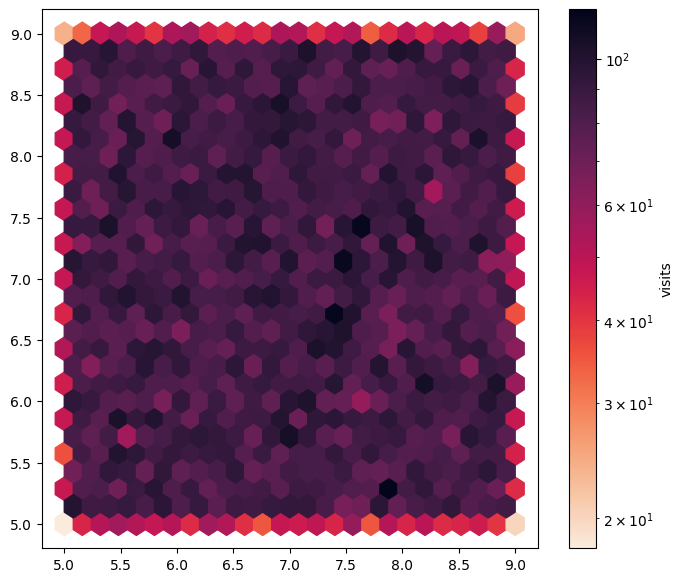

In [101]:
fig, ax = plt.subplots(figsize=(8, 7))
hb = ax.hexbin(df.p0, df.p1,
               gridsize=25, mincnt=1, bins="log", cmap="rocket_r")
fig.colorbar(hb, ax=ax, label="visits")
plt.show()

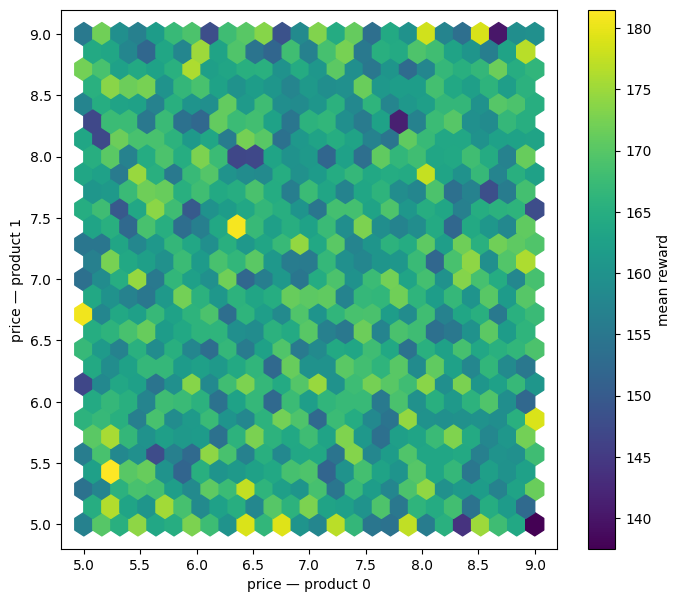

In [102]:
fig, ax = plt.subplots(figsize=(8, 7))
hb = ax.hexbin(df.p0, df.p1, C=df.reward,
               reduce_C_function=np.mean,
               gridsize=25, mincnt=5, cmap="viridis")
fig.colorbar(hb, ax=ax, label="mean reward")
ax.set_xlabel("price — product 0")
ax.set_ylabel("price — product 1")
plt.show()

In [78]:
print(len(df), df.p0.nunique(), df.p1.nunique(), counts.max().max())

60000 401 401 5.0
